In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
import os

#import scienceplots
#
#plt.style.use(['ieee','std-colors'])
#plt.rcParams.update({
#    "font.family": "serif",   # specify font family here
#    "font.serif": ["Times New Roman"],  # specify font here
#    "font.size":11})          # specify font size here


In [52]:
def plot_joint_states(joint_states, target="Position", fig=None, axs=None):
    n = joint_states.shape[1]
    
    if fig is None:
        if n == 3:
            fig, axs = plt.subplots(1, 3, figsize=(8, 4))
            fig.tight_layout(pad=5.0)
        else:
            fig, axs = plt.subplots(2, 3, figsize=(12, 8))
            fig.tight_layout(pad=5.0)

    for i, ax in enumerate(axs.flat):
        ax.plot(joint_states[:, i])
        ax.set_title(f'Joint {i+1}')
        ax.set_xlabel('Time')
        ax.set_ylabel(f'{target}')

    return fig, axs


In [53]:
exp_name = "NPThrowJerk"
model = "Throw_1hist_20Hz_100Limit_3muRobust" #"BR_20Hz_Full_DG, BR_20Hz_Robust_COM", "BR_20Hz_Robust_POS"
target = "Real"
library = "rl_games" #"skrl"
seed = 0
dataset_dir = f"../results/{library}/{exp_name}/{model}/{target}/seed{{}}"
traj_list = os.listdir(dataset_dir.format(seed))


In [54]:
succTrajs = []
block_pos_Error = []
ACTION = []
n_success = 0
n_drops = 0
for seed in range(1):
    results_dir = f"../results/{library}/{exp_name}/{model}/{target}/seed{{}}" #DYN_IL
    print("Results Directory: ", results_dir.format(seed))
    n = len(os.listdir(results_dir.format(seed))) - 1
    for i in range(n):
        traj_ind = "{:03d}".format(i)
        obs_traj = np.loadtxt(os.path.join(results_dir.format(seed), traj_ind,"obs_traj.txt"), delimiter=',')
        success_traj = np.loadtxt(os.path.join(results_dir.format(seed), traj_ind,"success_traj.txt"), delimiter=',')
        action_traj = np.loadtxt(os.path.join(results_dir.format(seed), traj_ind,"action_traj.txt"), delimiter=',')




        ee_pos = obs_traj[:, 12:15]*100
        object_pos = obs_traj[:, 27:30]*100
        object_relPos = object_pos - ee_pos

        #print(success_traj)
        is_success = (sum(success_traj)==len(success_traj))

        
        if is_success:
            #print("Success: ", traj_ind)
            n_success += 1  
            succTrajs.append(traj_ind)
            ACTION.append(action_traj)
        else:
            print("Drop: ", traj_ind)
            
print(f"n_success: {100*n_success/n}")
print(f"n_drops: {100*n_drops/n}")
print("Success Trajs: ", succTrajs)


Results Directory:  ../results/rl_games/NPThrowJerk/Throw_1hist_20Hz_100Limit_3muRobust/Real/seed0
n_success: 100.0
n_drops: 0.0
Success Trajs:  ['000', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '062', '063']


In [55]:
traj_ind = "002"
states_traj = np.loadtxt(os.path.join(dataset_dir.format(seed), traj_ind,"states_traj.txt"), delimiter=',')
# [block_state, ee_state, joint_state, target_pos, object_model], dim=-1
# "ObjectModel": torch.cat((self.block_mass, self.block_staticFriction, self.block_dynamicFriction, self.block_restitution, self.real_assets_sizes, self.block_com, self.x_shift.reshape(-1,1)), dim=-1),

block_pos = states_traj[:, :3]
block_quat = states_traj[:, 3:7]
block_vel = states_traj[:, 7:13]
post_throw = states_traj[:, 13]
ee_pos = states_traj[:, 14:17]
ee_quat = states_traj[:, 17:21]
ee_vel = states_traj[:, 21:27]
joint_pos = states_traj[:, 27:33]
joint_vel = states_traj[:, 33:39]
target_pos = states_traj[:, 39:42]
object_mass = states_traj[0, 42]
object_staticFriction = states_traj[0, 43]
object_dynamicFriction = states_traj[0, 44]
object_restitution = states_traj[0, 45]
object_length = states_traj[0, 46]
object_width = states_traj[0, 47]
object_height = states_traj[0, 48]
object_com = states_traj[0, 49:52]
x_shift = states_traj[0, 52]

# process quat into tilt angle
block_rot = R.from_quat(block_quat)
block_euler = block_rot.as_euler('xyz', degrees=True)
block_tilt = block_euler[:, 1]

ee_rot = R.from_quat(ee_quat)
ee_euler = ee_rot.as_euler('xyz', degrees=True)
ee_tilt = ee_euler[:, 1]

ee_pos = ee_pos #- ee_pos[0]  # shift to origin
robot_base = np.array([0.0, 0.0, 0.88])  # Assuming robot base is at the origin
ee_pos = ee_pos + robot_base  # Shift end-effector position to be relative to the robot base
block_pos = block_pos# - ee_pos[0]  # shift to origin


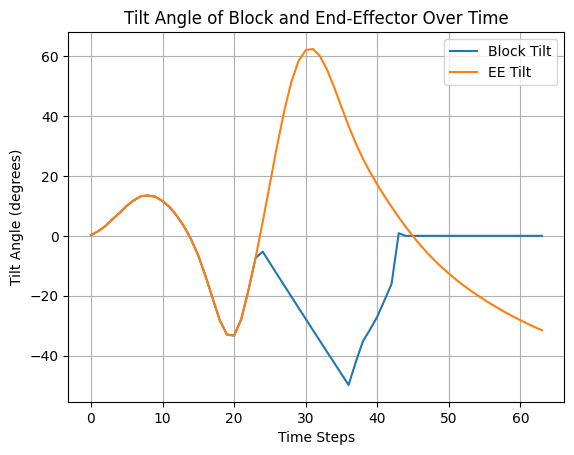

In [56]:
plt.plot(block_tilt, label="Block Tilt")
plt.plot(ee_tilt, label="EE Tilt")
plt.xlabel("Time Steps")
plt.ylabel("Tilt Angle (degrees)")
plt.title("Tilt Angle of Block and End-Effector Over Time")
plt.legend()
plt.grid()
plt.show()

[0.78498854 0.78986316 0.79624621 0.80458586 0.81251628 0.82132669
 0.8286017  0.83480647 0.83762502 0.83810832 0.83375002 0.82512638
 0.81016213 0.7905795  0.76663724]


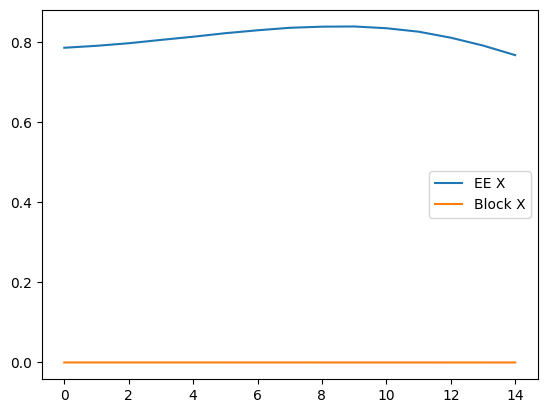

In [57]:
plt.plot(ee_pos[:15, 0], label="EE X")
plt.plot(block_pos[:15, 0], label="Block X")
plt.legend()

print(ee_pos[:15, 0]-block_pos[:15, 0])

Object Length:  0.20000000298023224
Object Height:  0.08500000089406967
EE Position:  [0.78498936 0.13329601 0.96809626]
Block Position:  [ 8.14665043e-07 -9.55758310e-07  4.24991697e-02]


(-0.5, 0.5)

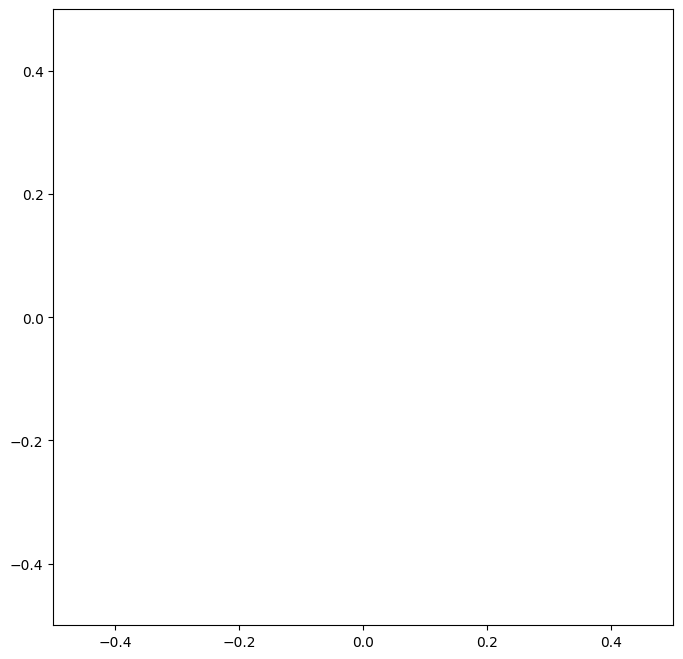

In [58]:
# visualize the motion of the block and the end-effector over time using the position and tilt angle 
# visualize using rectangles for the block and the end-effector

print("Object Length: ", object_length)
print("Object Height: ", object_height)
print("EE Position: ", ee_pos[0])
print("Block Position: ", block_pos[0])
ee_length = 0.2
ee_height = 0.05
# intial state
fig, ax = plt.subplots(figsize=(8, 8))
# add rectangle for the block
i = 10


ee = plt.Rectangle((ee_pos[i,0]-ee_length/2, ee_pos[i,2]-ee_height), ee_length, ee_height, edgecolor='black', facecolor='none',angle=ee_tilt[i],rotation_point=(ee_pos[i,0], ee_pos[i,2]))
ax.add_patch(ee)

theta_radians = np.radians(ee_tilt[i])
c, s = np.cos(theta_radians), np.sin(theta_radians)
Rot = np.array(((c, -s), (s, c)))


# Perform matrix multiplication to get the rotated vector
block_pos_i = Rot @ block_pos[i, [0,2]] + ee_pos[i, [0,2]]
block = plt.Rectangle((block_pos_i[0]-object_length/2, block_pos_i[1]-object_height/2), object_length, object_height, edgecolor='blue', facecolor='none',angle=block_tilt[i], rotation_point="center")
ax.add_patch(block)


ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.5, 0.5)


Object Length:  0.20000000298023224
Object Height:  0.08500000089406967


(-0.08260720121324994,
 0.9173927987867501,
 0.01743037678301329,
 1.0174303767830133)

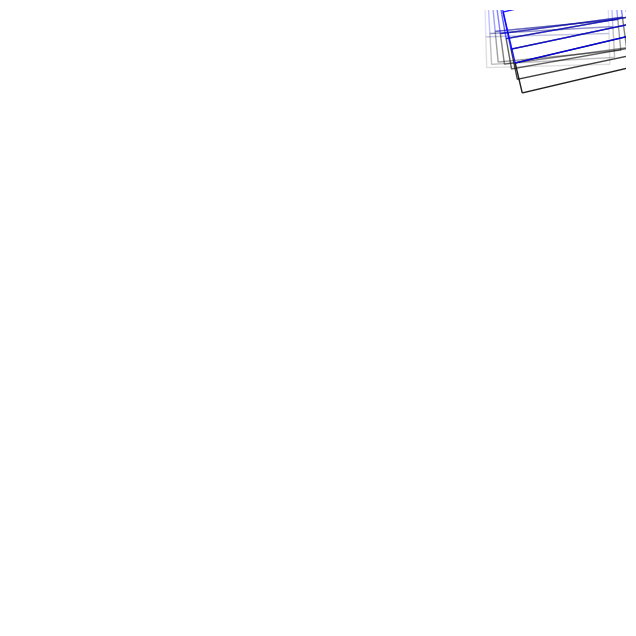

In [59]:
# visualize the motion of the block and the end-effector over time using the position and tilt angle 
# visualize using rectangles for the block and the end-effector
print("Object Length: ", object_length)
print("Object Height: ", object_height)

ee_length = 0.2
ee_height = 0.05
# intial state
fig, ax = plt.subplots(figsize=(8, 8))
# add rectangle for the block

n=len(block_pos)
N = 8
i_0 = 0
for i in range(i_0,i_0+N,1):
    
    ee = plt.Rectangle((ee_pos[i,0]-ee_length/2, ee_pos[i,2]-ee_height), ee_length, ee_height, edgecolor='black', facecolor='none',angle=ee_tilt[i],rotation_point=(ee_pos[i,0], ee_pos[i,2]),alpha=(i-i_0)/N)
    ax.add_patch(ee)

    theta_radians = np.radians(ee_tilt[i])
    c, s = np.cos(theta_radians), np.sin(theta_radians)
    Rot = np.array(((c, -s), (s, c)))


    # Perform matrix multiplication to get the rotated vector
    block_pos_i = Rot @ block_pos[i, [0,2]] + ee_pos[i, [0,2]]
    block = plt.Rectangle((block_pos_i[0]-object_length/2, block_pos_i[1]-object_height/2), object_length, object_height, edgecolor='blue', facecolor='none',angle=block_tilt[i], rotation_point="center", alpha=(i-i_0)/N)
    ax.add_patch(block)

minX= min(np.min(ee_pos[:i_0+N, 0]), np.min(block_pos[:i_0+N, 0]))
maxX= max(np.max(ee_pos[:i_0+N, 0]), np.max(block_pos[:i_0+N, 0]))
avgX = (minX + maxX)/2
minY= min(np.min(ee_pos[:i_0+N, 2]), np.min(block_pos[:i_0+N, 2]))
maxY= max(np.max(ee_pos[:i_0+N, 2]), np.max(block_pos[:i_0+N, 2]))
avgY = (minY + maxY)/2
ax.set_xlim(avgX-0.5, avgX+0.5)
ax.set_ylim(avgY-0.5, avgY+0.5)

plt.gca().set_aspect('equal')
# remove axis
plt.axis('off')

Object Length:  0.2
Object Height:  0.085


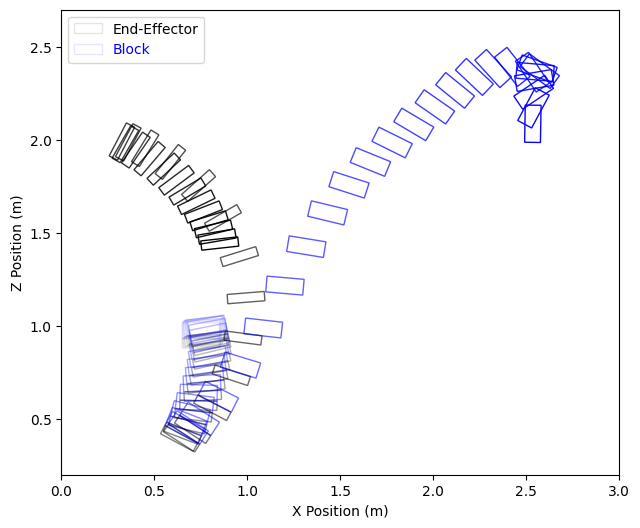

In [63]:
# visualize the motion of the block and the end-effector over time using the position and tilt angle 
# visualize using rectangles for the block and the end-effector
print("Object Length: ", object_length)
print("Object Height: ", object_height)

object_length = 0.2
object_height = 0.085
ee_length = 0.2
ee_height = 0.05
# intial state
fig, ax = plt.subplots(figsize=(8, 8))
# add rectangle for the block

n=len(block_pos)
N = 44
i_0 = 0
for i in range(i_0,i_0+N,1):
    
    ee = plt.Rectangle((ee_pos[i,0]-ee_length/2, ee_pos[i,2]-ee_height), ee_length, ee_height, edgecolor='black', facecolor='none',angle=ee_tilt[i],rotation_point=(ee_pos[i,0], ee_pos[i,2]),alpha=0.1 + 0.9*((i-i_0)/N)**0.9)
    ax.add_patch(ee)

    theta_radians = np.radians(ee_tilt[i])
    c, s = np.cos(theta_radians), np.sin(theta_radians)
    Rot = np.array(((c, -s), (s, c)))


    # Perform matrix multiplication to get the rotated vector
    block_pos_i = Rot @ block_pos[i, [0,2]] + ee_pos[i, [0,2]]

    block = plt.Rectangle((block_pos_i[0]-object_length/2, block_pos_i[1]-object_height/2), object_length, object_height, edgecolor='blue', facecolor='none',angle=block_tilt[i], rotation_point="center", alpha=0.1 + 0.9*((i-i_0)/N)**0.9)
    ax.add_patch(block)


minX= min(np.min(ee_pos[:i_0+N, 0]), np.min(block_pos[:i_0+N, 0]))
minY= min(np.min(ee_pos[:i_0+N, 2]), np.min(block_pos[:i_0+N, 2]))

ax.set_xlim(-0.0, 3)
ax.set_ylim(0.2, 2.7)
plt.gca().set_aspect('equal')
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Z Position (m)")
# add legend with blue for block and black for end-effector
ax.legend(["End-Effector", "Block"])
# color the legend boxes
legend = ax.get_legend()
legend.get_texts()[0].set_color('black')
legend.get_texts()[1].set_color('blue')
# remove axis
#plt.axis('off')
# image size 720x1280
plt.gcf().set_size_inches(7.2, 12.8)
# save the figure with high dpi and tight layout
plt.savefig("../plots/throw_trajectory.png", dpi=300, bbox_inches='tight')
plt.savefig("../plots/throw_trajectory.pdf", dpi=300, bbox_inches='tight')
plt.savefig("../plots/throw_trajectory.jpg", dpi=300, bbox_inches='tight')

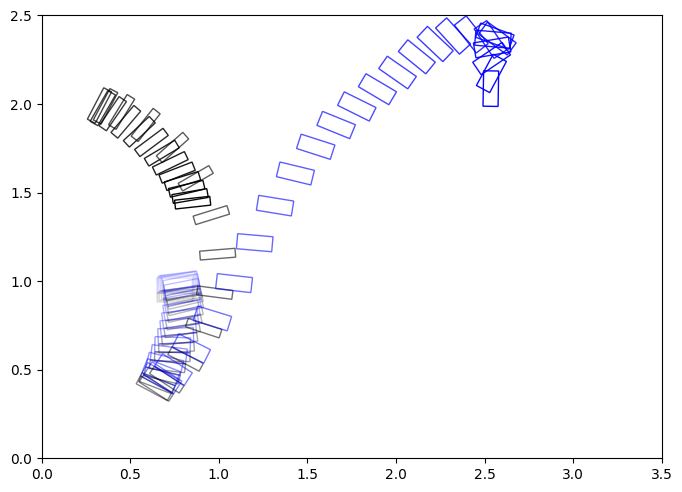

In [61]:
# visualize the motion of the block and the end-effector over time using the position and tilt angle 
# visualize using rectangles for the block and the end-effector
fig, ax = plt.subplots(figsize=(8, 8))

ee_colors = ['black', 'red', 'green']
block_colors = ['blue', 'orange', 'purple']
for ind, traj_ind in enumerate(["011", ]):
    states_traj = np.loadtxt(os.path.join(dataset_dir.format(seed), traj_ind,"states_traj.txt"), delimiter=',')
    # [block_state, ee_state, joint_state, target_pos, object_model], dim=-1
    # "ObjectModel": torch.cat((self.block_mass, self.block_staticFriction, self.block_dynamicFriction, self.block_restitution, self.real_assets_sizes, self.block_com, self.x_shift.reshape(-1,1)), dim=-1),

    block_pos = states_traj[:, :3]
    block_quat = states_traj[:, 3:7]

    # process quat into tilt angle
    block_rot = R.from_quat(block_quat)
    block_euler = block_rot.as_euler('xyz', degrees=True)
    block_tilt = block_euler[:, 1]

    ee_rot = R.from_quat(ee_quat)
    ee_euler = ee_rot.as_euler('xyz', degrees=True)
    ee_tilt = ee_euler[:, 1]

    ee_pos = states_traj[:, 14:17]
    ee_quat = states_traj[:, 17:21]
    robot_base = np.array([0.0, 0.0, 0.88])  # Assuming robot base is at the origin
    ee_pos = ee_pos + robot_base  # Shift end-effector position to be relative to the robot base

    object_length = states_traj[0, 46]
    object_height = states_traj[0, 48]

    ee_length = 0.2
    ee_height = 0.05
    # intial state
    # add rectangle for the block

    n=len(block_pos)
    N = 44
    i_0 = 0
    for i in range(i_0,i_0+N,1):
        
        ee = plt.Rectangle((ee_pos[i,0]-ee_length/2, ee_pos[i,2]-ee_height), ee_length, ee_height, edgecolor=ee_colors[ind], facecolor='none',angle=ee_tilt[i],rotation_point=(ee_pos[i,0], ee_pos[i,2]),alpha=0.1 + 0.9*(i-i_0)/N)
        ax.add_patch(ee)

        theta_radians = np.radians(ee_tilt[i])
        c, s = np.cos(theta_radians), np.sin(theta_radians)
        Rot = np.array(((c, -s), (s, c)))


        # Perform matrix multiplication to get the rotated vector
        block_pos_i = Rot @ block_pos[i, [0,2]] + ee_pos[i, [0,2]]

        block = plt.Rectangle((block_pos_i[0]-object_length/2, block_pos_i[1]-object_height/2), object_length, object_height, edgecolor=block_colors[ind], facecolor='none',angle=block_tilt[i], rotation_point="center", alpha=0.1 + 0.9*(i-i_0)/N)
        ax.add_patch(block)

ax.set_xlim(-0.0, 3.5)
ax.set_ylim(0.0, 2.5)
plt.gca().set_aspect('equal')
# remove axis
#plt.axis('off')